In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../')
import mlflow
import torch
from src.utils import helpers
from src.utils import visualization as vis
from src.utils.model_registry import MLFlowRegistry
from src.core.params import BaseParams
from src.core.exported_model import ExportedModel
from src.data.datamodule import CrowdDataModule

In [21]:
model, params = MLFlowRegistry().load_model('crowd_counting', version='11', run_id='f358e3d8201842b6964a6c980d3a8b42')

Model loaded from /teamspace/studios/this_studio/workspace/crowd_counting/trained_models/crowd_counting:11//data/model.pt2


In [22]:
model.predict(torch.randn(1,3,512,256))

(3.6327686309814453,
 tensor([[[3.8249e-13, 6.7203e-15, 2.0746e-18,  ..., 1.0843e-03,
           4.7471e-03, 9.9164e-03],
          [6.1792e-15, 6.0497e-17, 5.7987e-21,  ..., 3.9878e-04,
           2.1463e-03, 4.9746e-03],
          [1.6127e-18, 4.9024e-21, 4.5305e-26,  ..., 5.3913e-05,
           4.3799e-04, 1.2480e-03],
          ...,
          [2.9024e-05, 6.3144e-06, 2.9886e-07,  ..., 3.2306e-05,
           3.1804e-04, 9.9761e-04],
          [2.5695e-04, 7.6536e-05, 6.7896e-06,  ..., 2.7333e-04,
           1.6813e-03, 4.1661e-03],
          [7.6438e-04, 2.6644e-04, 3.2361e-05,  ..., 7.9488e-04,
           3.8627e-03, 8.5019e-03]]], device='cuda:0'))

In [23]:
datamodule = CrowdDataModule(params=params)
datamodule.setup(stage='fit')

In [24]:
sample, target, count = helpers.get_sample_from_dm(datamodule)
sample.shape

torch.Size([1, 3, 672, 992])

In [27]:
result_count, result  = model.predict(sample)
(result_count, result)

(19.362613677978516,
 tensor([[[8.5977e-07, 1.2621e-07, 2.7198e-09,  ..., 5.4821e-05,
           4.7181e-04, 1.3836e-03],
          [1.2307e-07, 1.3788e-08, 1.7306e-10,  ..., 1.4703e-05,
           1.6762e-04, 5.6588e-04],
          [2.5216e-09, 1.6455e-10, 7.0072e-13,  ..., 1.0576e-06,
           2.1153e-05, 9.4595e-05],
          ...,
          [1.3849e-06, 2.1680e-07, 5.3135e-09,  ..., 3.9741e-04,
           2.2177e-03, 5.2333e-03],
          [2.4253e-05, 5.6210e-06, 3.0193e-07,  ..., 2.0877e-03,
           8.0695e-03, 1.5827e-02],
          [1.0149e-04, 2.8621e-05, 2.2759e-06,  ..., 4.7805e-03,
           1.5359e-02, 2.7437e-02]]], device='cuda:0'))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


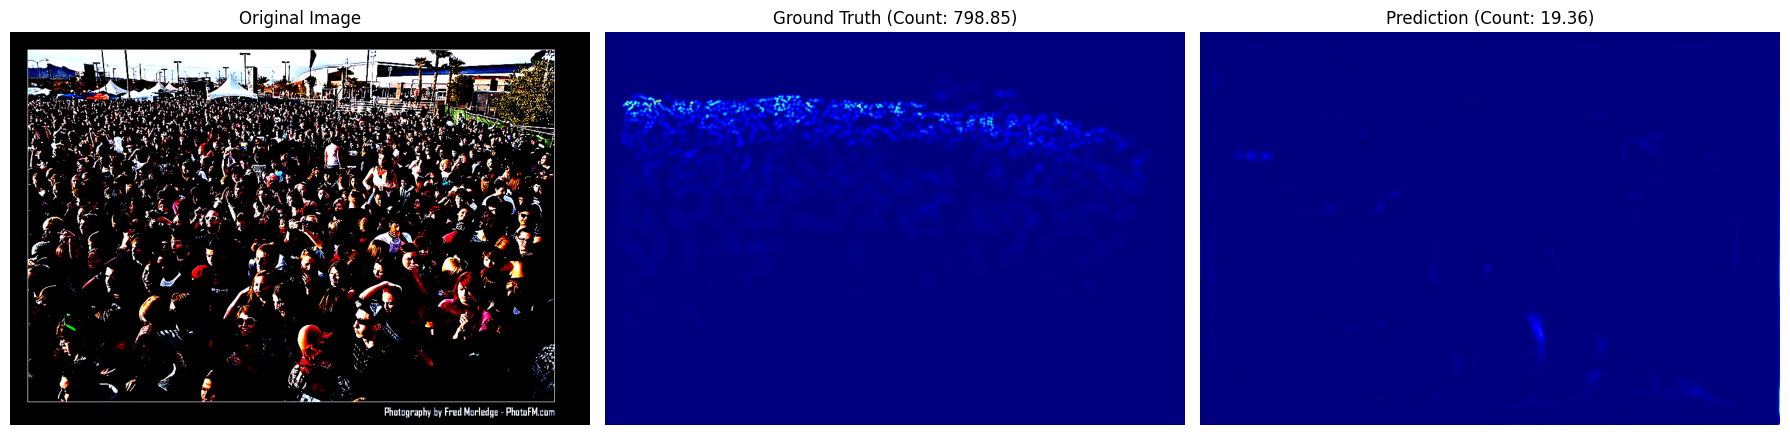

In [28]:
vis.visualize_sample(sample, target, result, count, result_count, )